Helper functions

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pandas as pd
import torch
from scipy.integrate import solve_ivp
from collections.abc import Callable
from typing import Tuple

# Helper: wrap a PyTorch model that takes a torch tensor of shape (N,) or (N,1)
def make_torch_wrapper(pt_model, device="cpu", batch_dim=False):
    """
    Wrap a PyTorch model so it can be called as a numpy function u -> out (numpy array).
    - pt_model should accept a torch tensor of shape (N,) or (N,1) and return (N,) or (N,1)
    - device: 'cpu' or 'cuda'
    - batch_dim: if True, the model expects input shape (batch, N) or similar; keep False for elementwise
    Returns: callable(u_numpy) -> numpy array
    """
    pt_model.to(device)
    pt_model.eval()
    def wrapper(u_np: np.ndarray) -> np.ndarray:
        # Convert to torch tensor
        with torch.no_grad():
            u_t = torch.from_numpy(u_np.astype(np.float32)).to(device)
            # If model expects shape (N,1), reshape
            if u_t.ndim == 1:
                u_t_in = u_t.unsqueeze(1)  # (N,1)
            else:
                u_t_in = u_t
            out = pt_model(u_t_in)
            # If out has shape (N,1) or (N,), convert to 1D numpy
            out_np = out.detach().cpu().numpy()
            out_np = out_np.reshape(u_np.shape)
        return out_np
    return wrapper

# reconstruct the solution using the learned NN 'D_model' at the training points (x_train, t_train)
def recon_solution(x_train, t_train, D_model, u_NN_IC):
    D_callable = make_torch_wrapper(D_model, device='cpu')
    u_sim = simulate_pde(x_train, u_NN_IC, D_callable,
                       t_span=(t_train[0], t_train[-1]),
                       t_eval=t_train,
                       integrator="RK45")
    return u_sim

# Simulate the PDE u_t = (D(u) u_x)_x with Neumann BCs using method of lines and solve_ivp
def simulate_pde(x: np.ndarray,
                 IC: np.ndarray,
                 D_callable: Callable[[np.ndarray], np.ndarray],
                 t_span: Tuple[float, float] = (0.0, 20.0),
                 t_eval: np.ndarray = None,
                 integrator: str = "RK45",
                 rtol: float = 1e-6,
                 atol: float = 1e-8,
                 save_path: str = None):
    """
    Simulate FKPP with BC: u_x=0 at boundaries (note: not no-flux BCs!).
    Inputs:
      x           : 1D grid (numpy array)
      IC          : initial condition (numpy array same length as x)
      D_callable  : function(u_array) -> D_array (same length as u)
      t_span      : (t0, tf)
      t_eval      : times to evaluate solution; default 201 points between t0 and tf
      integrator  : "RK45" or "BDF" etc; BDF recommended if stiff
      rtol, atol  : tolerances for solve_ivp
      save_path   : optional path to save final u as npy
    Returns:
      sol : the SciPy OdeResult-like object from solve_ivp (sol.y shape (N, len(t_eval)))
    """
    
    x = np.asarray(x)
    N = x.size
    dx = x[1] - x[0]
    assert IC.shape == x.shape, "IC must match x shape"
    if t_eval is None:
        t_eval = np.linspace(t_span[0], t_span[1], 201)

    def rhs(t, u_vec):
        u = np.asarray(u_vec)

        # Evaluate D at nodes
        Dn = D_callable(u)
        if Dn.shape != u.shape:
            raise ValueError("D_callable must return array of same shape as u")

        # Build ghost-point extension for Neumann BCs: u_x = 0
        u_ext = np.empty(N + 2, dtype=u.dtype)
        u_ext[1:-1] = u
        u_ext[0] = u[1]      # left ghost cell: u_{-1} = u_1
        u_ext[-1] = u[-2]    # right ghost cell: u_N = u_{N-2}

        # Extend D consistently
        Dn_ext = np.empty(N + 2, dtype=Dn.dtype)
        Dn_ext[1:-1] = Dn
        Dn_ext[0] = Dn[1]
        Dn_ext[-1] = Dn[-2]

        # D at interfaces
        D_half = 0.5 * (Dn_ext[:-1] + Dn_ext[1:])   # length N+1

        # Fluxes at interfaces
        flux = D_half * (u_ext[1:] - u_ext[:-1]) / dx   # length N+1

        # Divergence at physical nodes
        diffusion_term = (flux[1:] - flux[:-1]) / dx

        return diffusion_term
        
    sol = solve_ivp(rhs, t_span, IC, method=integrator, t_eval=t_eval, rtol=rtol, atol=atol)

    if not sol.success:
        print("Warning: solver reported failure:", sol.message)
    if save_path is not None:
        np.save(save_path, sol.y[:, -1])
        print(f"Saved final state to {save_path}")

    return sol.y.T


Plot formatting & setups

In [2]:
# plot formatting
plt.rcParams['font.family'] = 'overall_overall_times New Roman'
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.labelweight'] = 'bold'  # Bold axis labels
plt.rcParams['axes.titleweight'] = 'bold'  # Bold title
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.size'] = str(20)
plt.rcParams['lines.linewidth'] = 2

# epochs for training history
epoch_hist = np.arange(0, 4000, 1)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# time resolutions
Nt, t_end, t_min = 7, 18, 0.0
t_train = np.linspace(t_min, t_end, Nt)

# spatial resolutions
L = 7.0
x_min, x_max = -L, L
dx_long = 0.04
x_train = np.arange(x_min, x_max+dx_long, dx_long)
Nx = len(x_train)

# true solutions
D_true = 0.5 # true diffusivity
xx, tt = np.meshgrid(x_train, t_train)
u_true = 0.5 * np.cos(np.pi * xx / L) * np.exp(-tt * D_true * (np.pi**2) / (L**2)) + 0.5 # so that u in [0, 1]
u_min_np, u_max_np = u_true.min(), u_true.max()
U_grid= np.linspace(u_min_np, u_max_np, Nx)
X, T = np.meshgrid(x_train, t_train)
grid_points = np.vstack([X.flatten(), T.flatten()]).T
grid_points_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device)

# the variances we used 
variances = [0.0, 0.01, 0.001]
seed = 8

# batch_size, N_pde, N_bc
num_pts_data = np.array([
                    [10, 40, 40], 
                    [40, 40, 40], 
                    [160, 40, 40], 
                    [640, 40, 40]
                    ])
batch_sizes = [2, 10, 40, 160, 640]
colors = sns.color_palette("Set2", len(num_pts_data))
colors1 = sns.color_palette("Set1", 2)
alpha_val = 0.4

NumRep = 10

top_load_folder = '../ARCresults/Diffusion_linear/'
top_save_folder = '../Figures/Fig7/'
subfolders = ['batching_D_4_32_var0.0/', 'batching_D_4_32_var0.01/', 'batching_D_4_32_var0.001/']


### Plot: total validation loss and times spent by training BINNs based on different batch sizes

Processing variance 0.0...
Fitted parameters: a = 850.93, b = 1.32
Processing variance 0.01...
Fitted parameters: a = 849.34, b = 1.25
Processing variance 0.001...
Fitted parameters: a = 849.89, b = 1.31


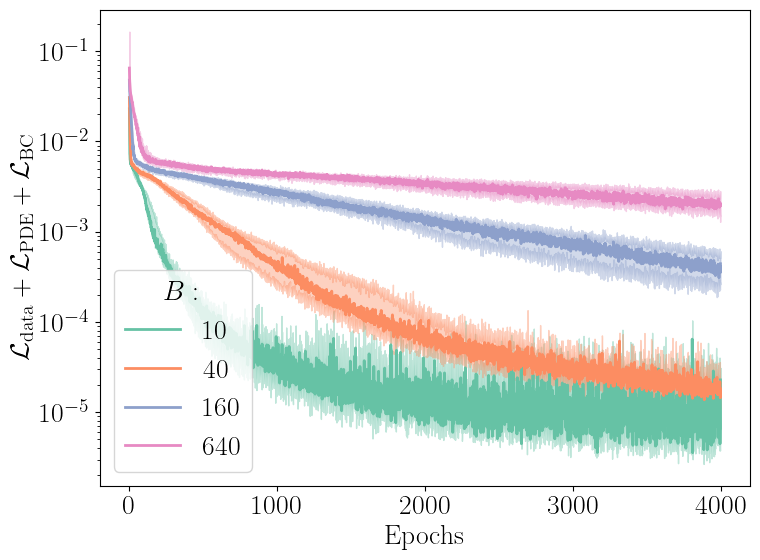

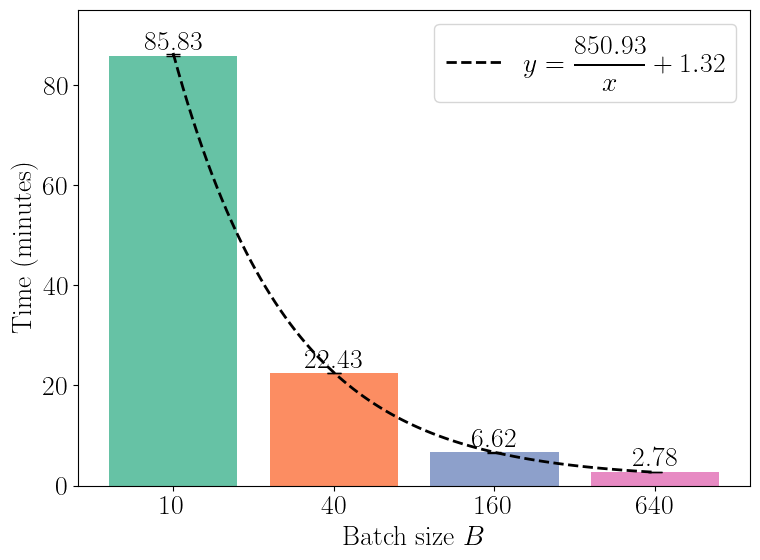

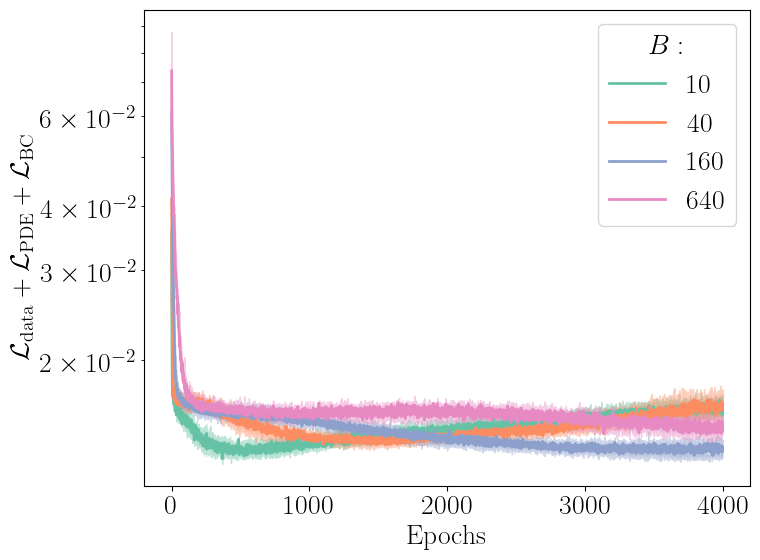

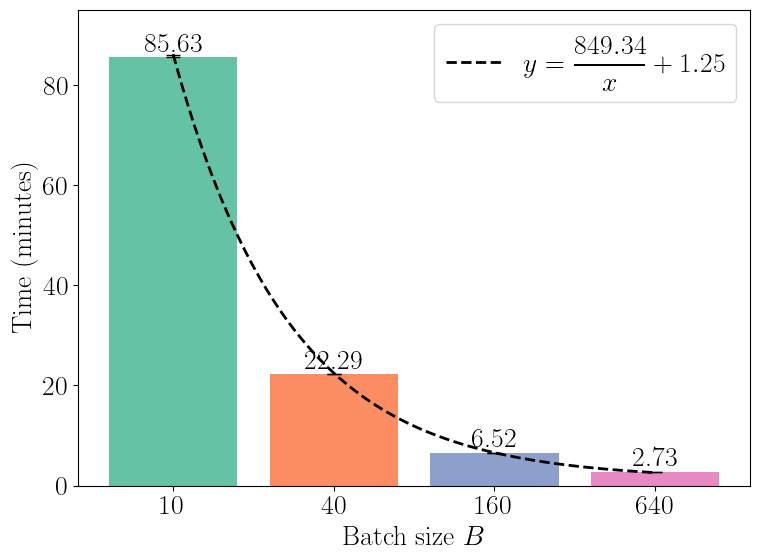

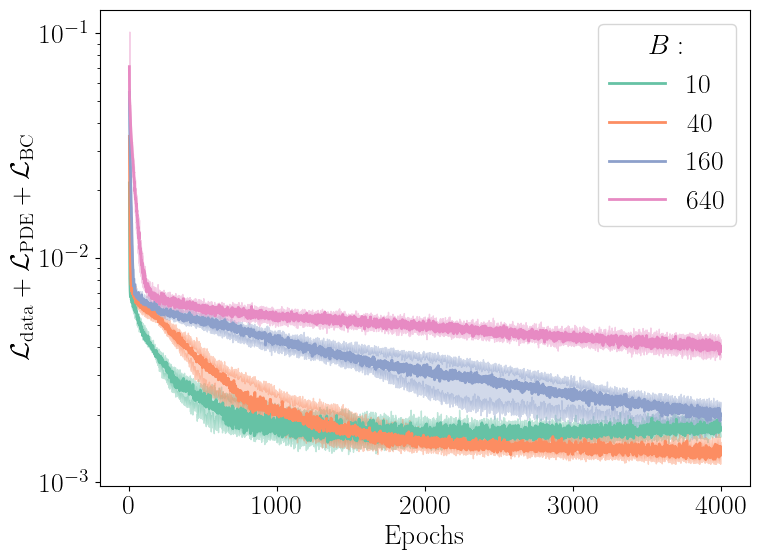

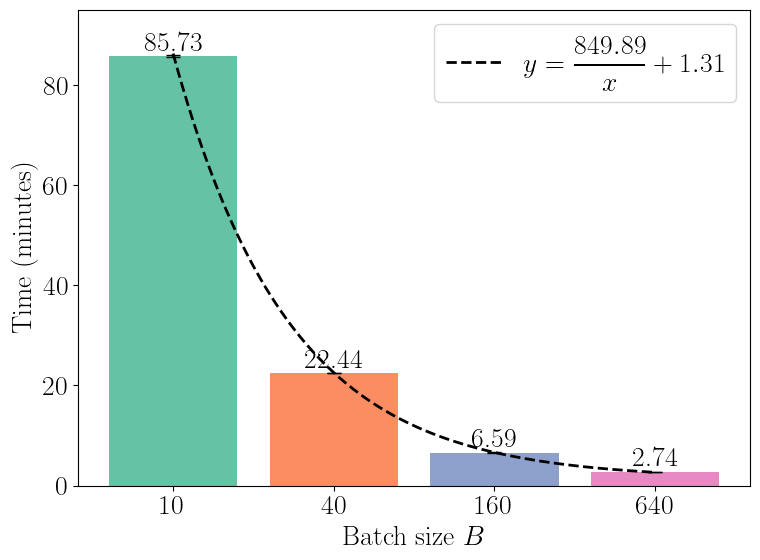

In [3]:
for var, subfolder in zip(variances, subfolders):
    print(f'Processing variance {var}...')

    load_dir = top_load_folder + subfolder
    save_dir = top_save_folder + f'var{var}/'

    fig1, ax1 = plt.subplots(figsize=(8, 6))
    fig2, ax2 = plt.subplots(figsize=(8, 6))

    overall_times, overall_times_median, overall_times_q1, overall_times_q3 = [], [], [], []

    for ind, pts in enumerate(num_pts_data):
        batch_size, N_pde, N_bc = pts
        batch_size, N_pde, N_bc = int(batch_size), int(N_pde), int(N_bc)
        label_ = f'{batch_size}'

        # load and plot loss curves
        loss_pde = np.load(load_dir + f'batchsize{batch_size}_Npde{N_pde}_Nbc{N_bc}/val_pdeloss_S.npy', allow_pickle=True)
        loss_data = np.load(load_dir + f'batchsize{batch_size}_Npde{N_pde}_Nbc{N_bc}/val_uloss_S.npy', allow_pickle=True)
        loss_bc = np.load(load_dir + f'batchsize{batch_size}_Npde{N_pde}_Nbc{N_bc}/val_BCloss_S.npy', allow_pickle=True)
        loss_data, loss_pde, loss_bc = np.asarray(loss_data, dtype=float), np.asarray(loss_pde, dtype=float), np.asarray(loss_bc, dtype=float)
        total_loss_ = np.array(loss_data) + np.array(loss_pde) + np.array(loss_bc)
        total_loss_median, total_loss_q1, total_loss_q3 = np.median(total_loss_, axis=0), np.percentile(total_loss_, 25, axis=0), np.percentile(total_loss_, 75, axis=0)
        ax1.plot(epoch_hist, total_loss_median, label=label_, color=colors[ind])
        ax1.fill_between(epoch_hist, total_loss_q1, total_loss_q3, color=colors[ind], alpha=alpha_val)

        # load and plot times
        times = np.load(load_dir + f'batchsize{batch_size}_Npde{N_pde}_Nbc{N_bc}/timeS.npy', allow_pickle=True)
        times = np.asarray(times, dtype=float)
        overall_times_median_val, overall_times_q1_val, overall_times_q3_val = np.median(times/60.0, axis=0), np.percentile(times/60.0, 25, axis=0), np.percentile(times/60.0, 75, axis=0)
        overall_times_median.append(overall_times_median_val)
        overall_times_q1.append(overall_times_q1_val)
        overall_times_q3.append(overall_times_q3_val)
        overall_times.append(times/60.0)
        ax2.bar(ind, overall_times_median_val, color=colors[ind])
        ax2.text(ind, overall_times_median_val, f'{overall_times_median_val:.2f}', ha='center', va='bottom')
        ax2.errorbar(ind, overall_times_median_val, yerr=[[overall_times_median_val - overall_times_q1_val], [overall_times_q3_val - overall_times_median_val]], fmt='none', ecolor='black', capsize=5)

    overall_times_median = np.array(overall_times_median)
    overall_times_q1 = np.array(overall_times_q1)
    overall_times_q3 = np.array(overall_times_q3)
    overall_times = np.array(overall_times)  # shape (batch sizes, NumRep)
    # now use least squares to fit the curve y = a/x + b to all these times 
    from scipy.optimize import curve_fit
    def model_func(x, a, b):
        return a / x + b
    batch_sizes = np.array([pts[0] for pts in num_pts_data])
    popt, pcov = curve_fit(model_func, np.repeat(batch_sizes, NumRep), overall_times.flatten())
    a_fit, b_fit = popt
    print(f'Fitted parameters: a = {a_fit:.2f}, b = {b_fit:.2f}')

    ax1.set_yscale('log')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel(r'$\mathcal{L}_{\mathrm{data}} + \mathcal{L}_{\mathrm{PDE}} + \mathcal{L}_{\mathrm{BC}}$')
    ax1.legend(title=r'$B:$', loc='best')

    batch_sizes = [pts[0] for pts in num_pts_data]
    x = np.arange(len(batch_sizes))
    ax2.set_xticks(x)
    ax2.set_xticklabels([str(b) for b in batch_sizes])
    ax2.set_xlabel('Batch size $B$')
    ax2.set_ylim(0, 95)
    ax2.set_ylabel('Time (minutes)')

    # also plot the curve y=200/x starting from the total time of the first bar
    first_bar_total = overall_times_median[0]
    x_vals = np.linspace(0, 3, 100)
    x_vals_ = 10 * (4**x_vals)
    y_vals = a_fit / x_vals_ + b_fit
    ax2.plot(x_vals, y_vals, 'k--', label=rf"$$y = \frac{{{a_fit:.2f}}}{{x}} + {b_fit:.2f}$$")
    ax2.legend()


    fig1.tight_layout()
    fig2.tight_layout()

    fig1.savefig(save_dir + f'total_valLoss_var{var}.svg', format='svg', bbox_inches='tight')
    fig2.savefig(save_dir + f'times_var{var}.svg', format='svg', bbox_inches='tight')

    

Loop through batch sizes to store L2RE for u_NN and u_reconstr under a fixed training time

In [8]:
fixedtime = 10
batch_sizes = [2, 10, 40, 160, 640]

for var, subfolder in zip(variances, subfolders):
    print(f'Processing variance {var}...')

    load_dir = top_load_folder + subfolder
    save_dir = top_save_folder + f'var{var}/'

    np.random.seed(seed)
    noise_level = np.sqrt(var)
    additive_noise = noise_level * np.random.randn(*u_true.shape)
    u_true_noisyIC = u_true + additive_noise

    l2RE_u_NN_all, l2RE_u_reconstr_all, u_reconstr_all =[], [], []

    for batch_size in batch_sizes:    

        D_net = torch.load(load_dir + f'FIXED{fixedtime}min_1e10epoch_batchsize{batch_size}_Npde40_Nbc40/Iter0/D_net_best_Iter0.pth', map_location=device, weights_only=False)
        u_net = torch.load(load_dir + f'FIXED{fixedtime}min_1e10epoch_batchsize{batch_size}_Npde40_Nbc40/Iter0/U_net_best_Iter0.pth', map_location=device, weights_only=False)
        u_net.eval()
        D_net.eval()

        # u_NN
        with torch.no_grad():
            u_NN = u_net(grid_points_tensor).cpu().numpy().reshape(len(t_train), len(x_train))
        l2RE_u = np.sqrt(np.sum((u_NN - u_true)**2)) / np.sqrt(np.sum(u_true**2))
        l2RE_u_NN_all.append(l2RE_u)

        # ------------------ YY -----------------
        # use the learnt u_NN at t=0 as the initial condition to reconstruct the solution
        u_NN_IC = u_NN[0, :]
        u_sim = recon_solution(x_train, t_train, D_net, u_NN_IC)
        u_reconstr_all.append(u_sim)
        l2RE_u_reconstr = np.sqrt(np.sum((u_sim - u_true)**2)) / np.sqrt(np.sum(u_true**2))
        l2RE_u_reconstr_all.append(l2RE_u_reconstr)


    l2RE_u_NN_all = np.array(l2RE_u_NN_all)
    l2RE_u_reconstr_all = np.array(l2RE_u_reconstr_all)
    u_reconstr_all = np.array(u_reconstr_all)

    # save
    np.save(save_dir + f'l2RE_u_NN_all_var{var}_FIXEDTIME{fixedtime}.npy', l2RE_u_NN_all)
    np.save(save_dir + f'l2RE_u_reconstr_all_var{var}_FIXEDTIME{fixedtime}.npy', l2RE_u_reconstr_all)
    np.save(save_dir + f'u_reconstr_all_var{var}_FIXEDTIME{fixedtime}.npy', u_reconstr_all)



Processing variance 0.0...
Processing variance 0.01...
Processing variance 0.001...


### Plot: L2RE u_NN and u_reconstr for different sizes under a fixed 120 min of training time

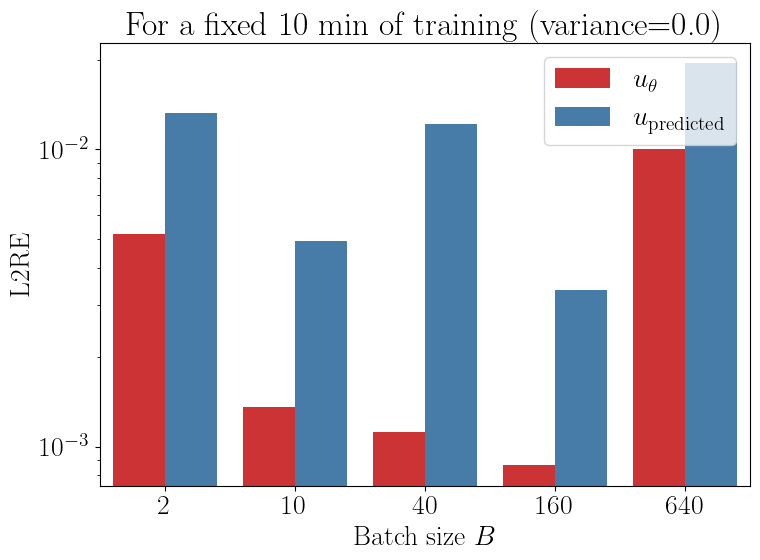

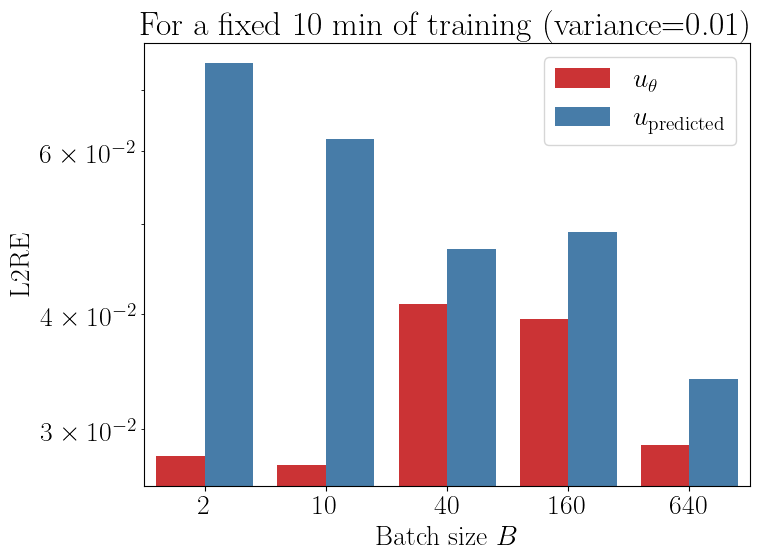

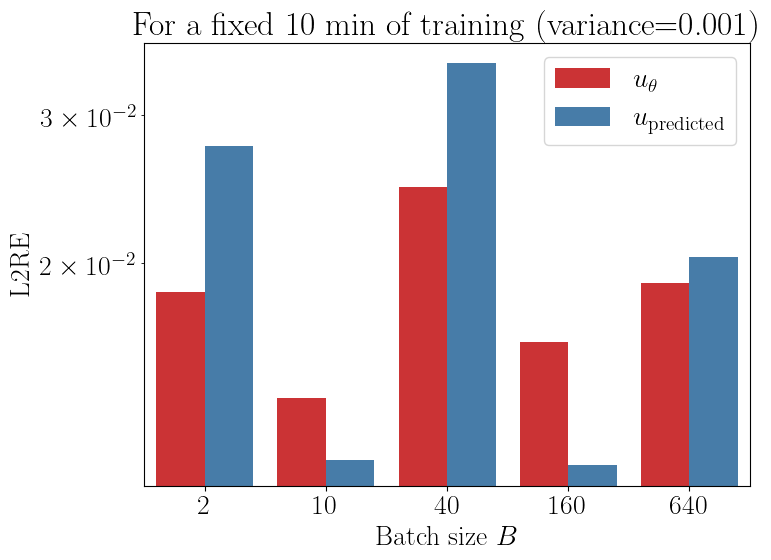

In [9]:
fixedtime = 10
batch_sizes = [2, 10, 40, 160, 640]

for var, subfolder in zip(variances, subfolders):

    save_dir = top_save_folder + f'var{var}/'

    errorS_uNN = np.load(save_dir + f'l2RE_u_NN_all_var{var}_FIXEDTIME{fixedtime}.npy')
    errorS_u_reconstr = np.load(save_dir + f'l2RE_u_reconstr_all_var{var}_FIXEDTIME{fixedtime}.npy')

    data = []
    for w_ind in range(len(batch_sizes)):
        batch_size = batch_sizes[w_ind]
        for rep in range(NumRep):
            data.append([batch_size, errorS_uNN[w_ind], r'$u_{\theta}$'])
            data.append([batch_size, errorS_u_reconstr[w_ind], r'$u_{\mathrm{predicted}}$'])
    df = pd.DataFrame(data, columns=[r'Batch size $B$', 'L2RE', 'Quantity'])

    fig, ax = plt.subplots(figsize=(8, 6))
    # MODIFIED: Set estimator to median and errorbar to 50% prediction interval (IQR)
    sns.barplot(
        x=r'Batch size $B$',
        y='L2RE',
        hue='Quantity',
        data=df,
        ax=ax,
        palette=colors1,
    )
    # Optional: Adjust x-axis labels to be scientific notation for clarity
    ax.set_yscale('log')
    legend = ax.get_legend()
    legend.set_title('')
    legend.set_loc('upper right')
    ax.set_title(f'For a fixed {fixedtime} min of training (variance={var})')
    fig.tight_layout()
    
    fig.savefig(save_dir + f'L2RE_uNN_u_reconstr{var}_FIXEDTIME{fixedtime}.svg', format='svg', bbox_inches='tight')




### Plot: losses under a fixed 10 min of training time

Processing variance 0.0...
Processing batch size 2...
Processing batch size 10...
Processing batch size 40...
Processing batch size 160...
Processing batch size 640...
Processing variance 0.01...
Processing batch size 2...
Processing batch size 10...
Processing batch size 40...
Processing batch size 160...
Processing batch size 640...
Processing variance 0.001...
Processing batch size 2...
Processing batch size 10...
Processing batch size 40...
Processing batch size 160...
Processing batch size 640...


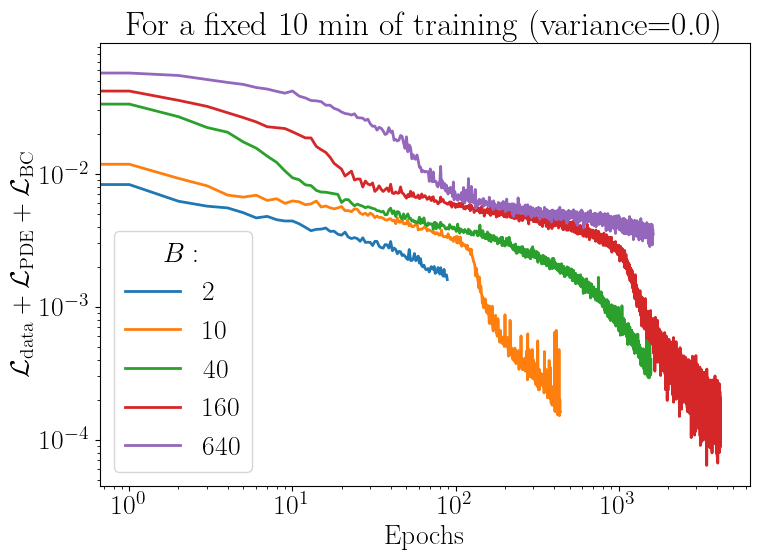

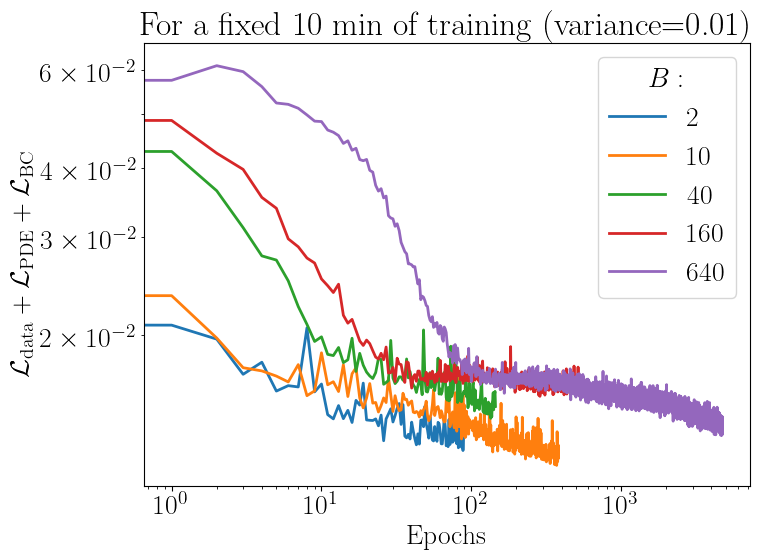

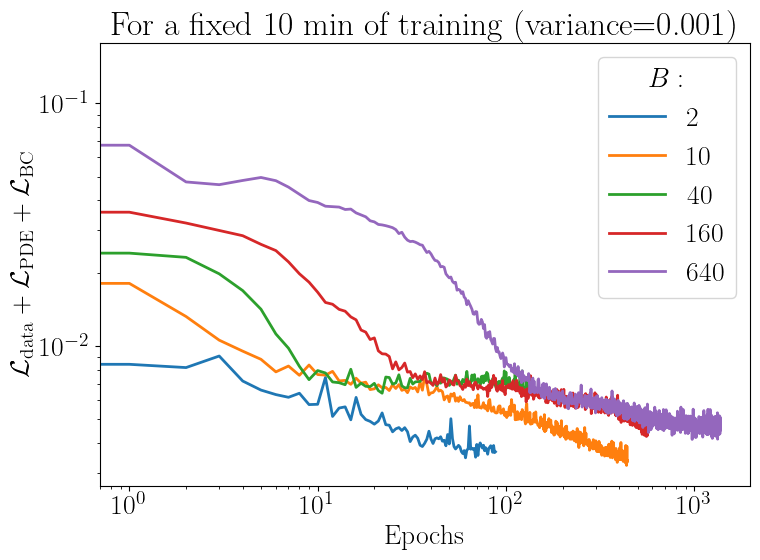

In [10]:
fixedtime = 10
batch_sizes = [2, 10, 40, 160, 640]

for var, subfolder in zip(variances, subfolders):
    print(f'Processing variance {var}...')

    load_dir = top_load_folder + subfolder
    save_dir = top_save_folder + f'var{var}/'

    fig1, ax1 = plt.subplots(figsize=(8, 6))

    max_epoch = 0

    for batch_size in batch_sizes:

        print(f'Processing batch size {batch_size}...')

        epoch_stop = np.load(load_dir + f'FIXED{fixedtime}min_1e10epoch_batchsize{batch_size}_Npde40_Nbc40/Iter0/epoch_history.npy')

        # load and plot loss curves
        loss_pde = np.load(load_dir + f'FIXED{fixedtime}min_1e10epoch_batchsize{batch_size}_Npde40_Nbc40/Iter0/val_pdeloss_history.npy')
        loss_data = np.load(load_dir + f'FIXED{fixedtime}min_1e10epoch_batchsize{batch_size}_Npde40_Nbc40/Iter0/val_uloss_history.npy')
        loss_bc = np.load(load_dir + f'FIXED{fixedtime}min_1e10epoch_batchsize{batch_size}_Npde40_Nbc40/Iter0/val_BCloss_history.npy')
        loss_data, loss_pde, loss_bc = np.asarray(loss_data, dtype=float), np.asarray(loss_pde, dtype=float), np.asarray(loss_bc, dtype=float)
        total_loss_ = loss_data + loss_pde + loss_bc

        ax1.plot(epoch_stop, total_loss_, label=f'{batch_size}')
        

    
    ax1.set_yscale('log')
    ax1.set_xscale('log')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel(r'$\mathcal{L}_{\mathrm{data}} + \mathcal{L}_{\mathrm{PDE}} + \mathcal{L}_{\mathrm{BC}}$')
    ax1.legend(title=r'$B:$', loc='best')
    ax1.set_title(f'For a fixed {fixedtime} min of training (variance={var})')
    fig1.tight_layout()

    fig.savefig(save_dir + f'total_valLoss_var{var}_FIXEDTIME{fixedtime}.svg', format='svg', bbox_inches='tight')